# Optimization for Robotics Summer School 2025

## 14-18 July, 2025, University of Patras, Greece

**Instructor:** Konstantinos Chatzilygeroudis (costashatz@upatras.gr)

<div>
<img src="attachment:a9599451-1a2d-4832-9c1e-bd834d765dec.png" width="300"/>
</div>

## Monday Practicals - Optimization I

### Gradients, Jacobians and Hessians

Let's start by computing the gradient and the derivative (Leibniz's notation) of a scalar function with vector-valued inputs. We have this nice quadratic:

$f(\boldsymbol{x}) = \frac{1}{2}\boldsymbol{x}^T\boldsymbol{Q}\boldsymbol{x}$

where $\boldsymbol{x}\in{\mathbb{R}^{3\times 1}}$ (column vector).

Let's begin by writing a Python function, `f()`, that computes the value:

In [1]:
# Imports
import numpy as np # Linear Algebra
import scipy # For matrix exponential
import matplotlib.pyplot as plt # Plotting

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
Q = np.diag([0.1, 0.5, 1.]) # Global var for ease of use

def f(x):
    x = 0.5 * x.T @ Q @ x # Quadratic form,
    return x
    ### TO-DO: Write the function! It should return a scalar!
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION

In [3]:
x = np.array([[2., 1., 2.]]).T
assert(np.isclose(f(x), 2.45))

x = np.array([[-2., -1., -2.]]).T
assert(np.isclose(f(x), 2.45))

x = np.array([[-2., -1., 2.]]).T
assert(np.isclose(f(x), 2.45))

x = np.array([[-2., -1., 3.]]).T
assert(np.isclose(f(x), 4.95))

x = np.array([[-5., -1., 3.]]).T
assert(np.isclose(f(x), 6.))

The gradient of $f$ is denoted as $\nabla_{\boldsymbol{x}}f\in\mathbb{R}^{3\times 1}$ (column vector). Let's write a function in Python, `gradf()`, that computes this:

In [4]:
def gradf(x):
    ### TO-DO: Write the gradient of f
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION
    return Q @ x

On the other hand, the derivative of $f$ is denoted as $\frac{\partial f}{\partial\boldsymbol{x}}\in\mathbb{R}^{1\times 3}$ (row vector). Let's write a function in Python, `df()`, that computes this:

In [5]:
def df(x):
    ### TO-DO: Write the derivative of f
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION
    return gradf(x).T

Are the two functions computing the same thing!? Let's find out:

In [6]:
x0 = np.array([[-2., 1., 4.]]).T

gf = gradf(x0)
dfdx = df(x0)

print(gf)
print(dfdx)

[[-0.2]
 [ 0.5]
 [ 4. ]]
[[-0.2  0.5  4. ]]


What is the difference!? Basically, $\nabla_{\boldsymbol{x}}f(\boldsymbol{x}_0) = \frac{\partial f}{\partial\boldsymbol{x}}\Big|_{\boldsymbol{x}=\boldsymbol{x}_0}^T$. Let's verify this!

In [7]:
print(np.linalg.norm(gf-dfdx.T))

assert(np.isclose(gf, dfdx.T).all())

for _ in range(20):
    x0 = np.random.randn(3, 1)
    gf = gradf(x0)
    dfdx = df(x0)
    assert(np.isclose(gf, dfdx.T).all())

x = np.array([[2., 1., 2.]]).T
assert(np.isclose(df(x), np.array([[0.2, 0.5, 2.]])).all())

x = np.array([[-2., -1., -2.]]).T
assert(np.isclose(df(x), np.array([[-0.2, -0.5, -2.]])).all())

x = np.array([[-2., -1., 2.]]).T
assert(np.isclose(df(x), np.array([[-0.2, -0.5, 2.]])).all())

x = np.array([[-2., -1., 3.]]).T
assert(np.isclose(df(x), np.array([[-0.2, -0.5, 3.]])).all())

x = np.array([[-5., -1., 3.]]).T
assert(np.isclose(df(x), np.array([[-0.5, -0.5, 3.]])).all())

0.0


Now let's compute the Hessian of `f()` compactly:

In [8]:
def hessf(x):
    ### TO-DO: Write the Hessian of f
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION
    return Q

In [9]:
x0 = np.random.randn(3, 1)
x1 = np.random.randn(3, 1)
assert(np.isclose(hessf(x0), hessf(x1)).all())

Now let's create a vector-valued function $f(\cdot):\mathbb{R}^N\to\mathbb{R}^M$. Let's do the **uncontrolled** pendulum:

In [10]:
def pendulum(x, l = 1., g = 9.81):
    theta_ddot = (-g/l)*np.sin(x[:1])

    return np.concatenate([x[1:], theta_ddot], axis=0)

Let's write the Jacobian of this. But first, let's remind ourselves what the Jacobian is:

For $\boldsymbol{y} = f(\boldsymbol{x}) : \mathbb{R}^N\to\mathbb{R}^M$, we have:

$\frac{\partial f}{\partial\boldsymbol{x}} = \begin{bmatrix}\frac{\partial\boldsymbol{y}_1}{\partial\boldsymbol{x}_1} & \frac{\partial\boldsymbol{y}_1}{\partial\boldsymbol{x}_2} & \dots & \frac{\partial\boldsymbol{y}_1}{\partial\boldsymbol{x}_N}\\\frac{\partial\boldsymbol{y}_2}{\partial\boldsymbol{x}_1} & \frac{\partial\boldsymbol{y}_2}{\partial\boldsymbol{x}_2} & \dots & \frac{\partial\boldsymbol{y}_2}{\partial\boldsymbol{x}_N}\\\ddots & \ddots & \ddots & \ddots\\\frac{\partial\boldsymbol{y}_M}{\partial\boldsymbol{x}_1} & \frac{\partial\boldsymbol{y}_M}{\partial\boldsymbol{x}_2} & \dots & \frac{\partial\boldsymbol{y}_M}{\partial\boldsymbol{x}_N}\end{bmatrix}\in\mathbb{R}^{M\times N}$

In [11]:
def deriv_pendulum(x, l = 1., g = 9.81):
    ### TO-DO: Write the Jacobian of `pendulum()`
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION
    theta = x[0, 0]

    # Construct the 2x2 Jacobian matrix. Now that theta is a scalar,
    # this will correctly create a standard NumPy array.
    dx = np.array([
        [0., 1.],
        [-(g / l) * np.cos(theta), 0.]
    ])
    ### END SOLUTION
    return dx

In [12]:
# Let's test it
x0 = np.array([[0.1, 0.]]).T
dx0 = np.array([[0., 1.], [-9.76099086, 0.]])
assert(np.isclose(deriv_pendulum(x0), dx0).all())

x0 = np.array([[0.1, 10.]]).T
assert(np.isclose(deriv_pendulum(x0), dx0).all())

x0 = np.array([[-20., 0.]]).T
dx0 = np.array([[0., 1.], [-4.00328503, 0.]])
print(deriv_pendulum(x0))
assert(np.isclose(deriv_pendulum(x0), dx0).all())

[[ 0.          1.        ]
 [-4.00328503  0.        ]]


### Newton's Method

Let's remember the Newton's method for **root finding**:

1) We first linearize around the current estimate $\boldsymbol{x}_k$:

$f(\boldsymbol{x}_k + \Delta\boldsymbol{x})\approx f(\boldsymbol{x}_k) + \frac{\partial f}{\partial\boldsymbol{x}}\Big|_{\boldsymbol{x}_k}\Delta\boldsymbol{x}$

2) We then set $f(\boldsymbol{x}_k + \Delta\boldsymbol{x}) = 0$ and solve for $\Delta\boldsymbol{x}$:

$f(\boldsymbol{x}_k) + \frac{\partial f}{\partial\boldsymbol{x}}\Big|_{\boldsymbol{x}_k}\Delta\boldsymbol{x} = 0$

$\Delta\boldsymbol{x} = -\Big(\frac{\partial f}{\partial\boldsymbol{x}}\Big|_{\boldsymbol{x}_k}\Big)^{-1}f(\boldsymbol{x}_k)$

3) We apply the correction $\boldsymbol{x}_{k+1} = \boldsymbol{x}_k + \Delta\boldsymbol{x}$

4) Repeat until convergence

Let's try the newton method on our `pendulum()`!

In [13]:
# Initial guess
x0 = np.array([[0.5, 0.]]).T

# Step for newton (we start at a big one to enable the while loop)
dx = np.ones((2,1))

def newton_root_finding_step(x):
    ### TO-DO: Write Newton's method step for Root Finding.
    ### You should compute the Δx (store it in a variable named `dx`)
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION
    fx = pendulum(x)
    dfx = deriv_pendulum(x)
    dx = -np.linalg.inv(dfx) @ fx
    return x + dx, dx

# iterate
x = np.copy(x0)
iters = 0
while np.linalg.norm(dx) > 1e-6:
    x, dx = newton_root_finding_step(x)
    iters += 1

print("Found x:", x.T, "->", pendulum(x).T, "in", iters, "iterations!")

Found x: [[0. 0.]] -> [[ 0. -0.]] in 4 iterations!


In [14]:
x0 = np.array([[0.5, 0.]]).T
x, dx = newton_root_finding_step(x0)
assert(np.isclose(dx, np.array([[-0.54630249], [0.]]), rtol=1e-3).all())

x0 = np.array([[np.pi - 0.1, 0.]]).T
x, dx = newton_root_finding_step(x0)
assert(np.isclose(dx, np.array([[0.1], [0.]]), rtol=1e-3, atol=1e-3).all())

### Newton's Method for Optimization

Let's optimize `f()`! Not `pendulum()`, but the function `f()` with first defined!

How can we do that with Newton's Method? We frame the optimization problem as a root finding problem at the gradient of $f$! Let's remember the procedure:

$\nabla_{\boldsymbol{x}}f(\boldsymbol{x}_k + \Delta\boldsymbol{x}) \approx \nabla_{\boldsymbol{x}}f(\boldsymbol{x}_k) + \frac{\partial}{\partial\boldsymbol{x}}\Big(\nabla_{\boldsymbol{x}}f(\boldsymbol{x}_k)\Big)\Delta\boldsymbol{x} = 0$

$\nabla_{\boldsymbol{x}}f(\boldsymbol{x}_k + \Delta\boldsymbol{x}) \approx \nabla_{\boldsymbol{x}}f(\boldsymbol{x}_k) + \nabla^2_{\boldsymbol{x}}f(\boldsymbol{x}_k)\Delta\boldsymbol{x} = 0$

$\Delta\boldsymbol{x} = -\Big(\nabla^2_{\boldsymbol{x}}f(\boldsymbol{x}_k)\Big)^{-1}\nabla_{\boldsymbol{x}}f(\boldsymbol{x}_k)$

$\boldsymbol{x}_{k+1} = \boldsymbol{x}_k + \Delta\boldsymbol{x}$

Cool! Let's do this on `f()`:

In [15]:
# Initial point
x0 = np.array([[-2., 1., 4.]]).T

# Step for newton (we start at a big one to enable the while loop)
dx = np.ones((3,1))

def newton_step(x):
    ### TO-DO: Write Newton's method step for Optimization
    ### You should compute the Δx (store it in a variable named `dx`)
    ### Do not forget to update x with Δx!
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION
    fx = gradf(x)
    dfx = hessf(x)
    dx = -np.linalg.inv(dfx) @ fx
    return x + dx, dx

# iterate
x = np.copy(x0)
iters = 0
while np.linalg.norm(dx) > 1e-6:
    x, dx = newton_step(x)
    iters += 1

print("Found x:", x.T, "->", f(x), "in", iters, "iterations!")

Found x: [[0. 0. 0.]] -> [[0.]] in 2 iterations!


In [16]:
x0 = np.array([[-2., 1., 4.]]).T
x, dx = newton_step(x0)
assert(np.isclose(dx, -x0, rtol=1e-3).all())

x0 = np.array([[20., 10., 40.]]).T
x, dx = newton_step(x0)
assert(np.isclose(dx, -x0, rtol=1e-3, atol=1e-3).all())

for _ in range(100):
    x0 = np.random.randn(3, 1)
    x, dx = newton_step(x0)
    assert(np.isclose(dx, -x0, rtol=1e-3, atol=1e-3).all())

Wow! This was fast convergence! Only **2** iterations! Try putting the initial point far away! In convex functions (like our function), Newton's method has **quadratic convergence rate**: this basically means **blazingly fast!!** Notice also that we used the autodiff gradients/Hessian from *jax*!

### Practical Newton's Method (with tricks)

In practice, Newton's method can *maximize* instead of minimizing and also overshoot the local minimum, oscillate or even explode! Let's start optimizing a harder function and see how we can address those issues of Newton's method.

Let's try to optimize the [Rastrigin Function](https://www.sfu.ca/~ssurjano/rastr.html) in 2D. Let's plot it to see how it looks:

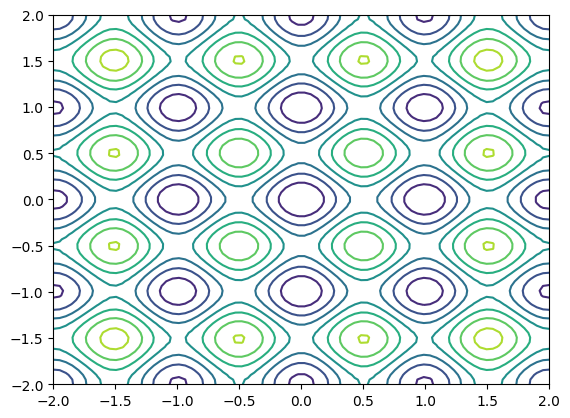

In [17]:
def f(x):
    A = 10.
    d = x.shape[0]
    return A * d + np.sum(x.T @ x) - A * np.sum(np.cos(2. * np.pi * x))

plt.close()
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

N = 80
x1 = np.linspace(-2., 2., N)
x2 = np.linspace(-2., 2., N)

X, Y = np.meshgrid(x1, x2)

val = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        xx = np.zeros((2, 1))
        xx[0] = X[i, j]
        xx[1] = Y[i, j]
        val[i, j] = f(xx)

CS = ax.contour(x1.reshape((N,)), x2.reshape((N,)), val)

Nice function with many many local minima! Let's use Newton's method on this!

In [18]:
# First let's compute its derivatives!
def df_dx(x):
    A = 10.
    ### TO-DO: Compute and return the derivative of f(x) (Rastrigin)
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION
    return 2 * x.T + 2 * np.pi * A * np.sin(2. * np.pi * x.T)    

def ddf_ddx(x):
    A = 10.
    ### TO-DO: Compute and return the Hessian of f(x) (Rastrigin)
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION
    diagonal_elements = 2 + 4 * (np.pi**2) * A * np.cos(2 * np.pi * x.T)
    return np.diag(diagonal_elements.flatten())

In [19]:
def finite_diff(f, z, M, eps = 1e-4):
    N = z.shape[0]
    jac = np.zeros((M, N))
    v = np.zeros((N, 1))
    for i in range(N):
        zp = np.copy(z)
        v[i] = eps
        zp = zp + v
        zm = np.copy(z)
        v[i] = -eps
        zm = zm + v
        jac[:, i:i+1] = (((f(zp) - f(zm))) / (2. * eps)).reshape((-1, 1))
    return jac

for _ in range(100):
    x = np.random.randn(2, 1)
    assert(np.isclose(finite_diff(f, x, 1), df_dx(x), rtol=1e-3, atol=1e-3).all())
    assert(np.isclose(finite_diff(df_dx, x, x.shape[0]), ddf_ddx(x), rtol=1e-3, atol=1e-3).all())

Initial value: 14.580169943749475


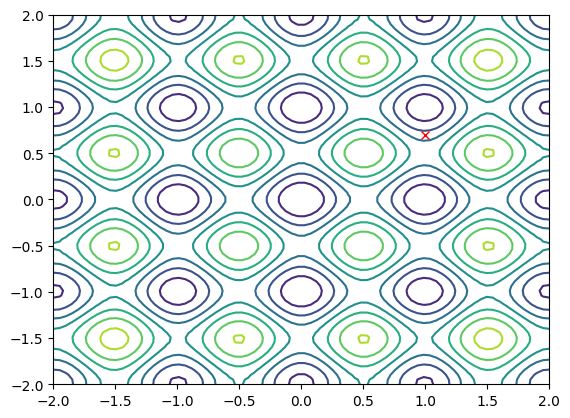

In [20]:
# Initial point
x0 = np.array([[1., 0.7]]).T
# x0 = np.array([[1., 1.25]]).T # Uncomment and watch it explode!

ax.plot(x0[0, 0], x0[1, 0], 'rx')

print("Initial value:", f(x0))

fig # show figure again with updated point(s)

In [21]:
def newton_step(x):
    ### TO-DO: Write Newton's method step for Optimization
    ### Compute Δx (store it in a variabe named `dx`)
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION
    jacobian = df_dx(x)
    
    gradient = jacobian.T
    hessian = ddf_ddx(x)
    dx = -np.linalg.inv(hessian) @ gradient
    return x + dx

In [22]:
np.random.seed(10)

x = np.random.randn(2, 1)
xn = newton_step(x)
assert(np.isclose(xn, np.array([[1.63122303, -0.0027116]]).T, rtol=1e-3, atol=1e-3).all())

x = np.random.randn(2, 1)
xn = newton_step(x)
assert(np.isclose(xn, np.array([[-1.50668149, 0.]]).T, rtol=1e-3, atol=1e-3).all())

x = np.random.randn(2, 1)
xn = newton_step(x)
assert(np.isclose(xn, np.array([[0.47265641, 0.11992915]]).T, rtol=1e-3, atol=1e-3).all())

np.random.seed(None)

In [23]:
# Let's start solving
x = np.copy(x0)

x: [[0.99495948 0.21367445]] -> 8.777979354707096


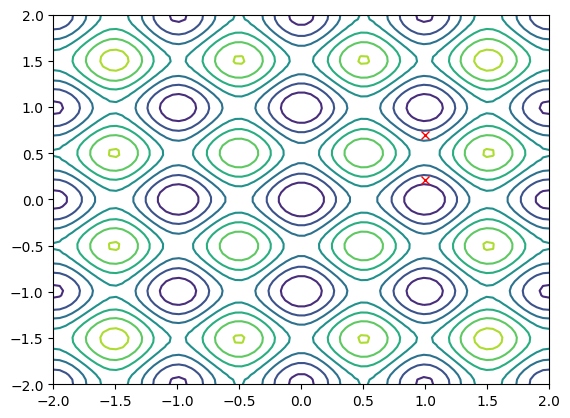

In [24]:
# iterate
x = newton_step(x)
print("x:", x.T, "->", f(x))

ax.plot(x[0, 0], x[1, 0], 'rx')

fig # show figure again with updated point(s)

We find a local maximum! **AND** we can easily explode! Let's fix that with **damping** and **Line search**. Let's remind ourselves of the damping procedure (this helps to always minimize and regularize the optimizer):

$\boldsymbol{H} = \nabla^2_{\boldsymbol{x}}f(\boldsymbol{x}_k)$

$\text{while } \boldsymbol{H}\preceq 0:$

$\quad\boldsymbol{H} = \boldsymbol{H} + \beta\boldsymbol{I}$

$\Delta\boldsymbol{x} = -\boldsymbol{H}^{-1}\nabla_{\boldsymbol{x}}f(\boldsymbol{x}_k)$

$\boldsymbol{x}_{k+1} = \boldsymbol{x}_k + \Delta\boldsymbol{x}$

Let's create a function that does the **damped Netwon's iterate** (aka one step):

In [25]:
def is_pos_def(x):
    return np.all(np.linalg.eigvals(x) > 0)

def damped_newton_step(x, beta = 100.):
    ### TO-DO: Implement Damped Newton step
    ### Compute Δx (store it in a variabe named `dx`)
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION
    jacobian = df_dx(x)
    
    gradient = jacobian.T
    hessian = ddf_ddx(x)

    d = hessian.shape[0]
    I = np.eye(d)

    while not is_pos_def(hessian):
        hessian += (beta) * I

    dx = -np.linalg.inv(hessian) @ gradient
    return x + dx

In [26]:
np.random.seed(10)

x = np.random.randn(2, 1)
xn = damped_newton_step(x)
assert(np.isclose(xn, np.array([[-5.52664708, 1.22929842]]).T, rtol=1e-3, atol=1e-3).all())

x = np.random.randn(2, 1)
xn = damped_newton_step(x)
assert(np.isclose(xn, np.array([[-2.17512681, -0.00420789]]).T, rtol=1e-3, atol=1e-3).all())

x = np.random.randn(2, 1)
xn = damped_newton_step(x)
assert(np.isclose(xn, np.array([[3.177012, -0.98422351]]).T, rtol=1e-3, atol=1e-3).all())

np.random.seed(None)

Let's optimize the Rastrigin function with our new function:

Initial value: 14.580169943749475


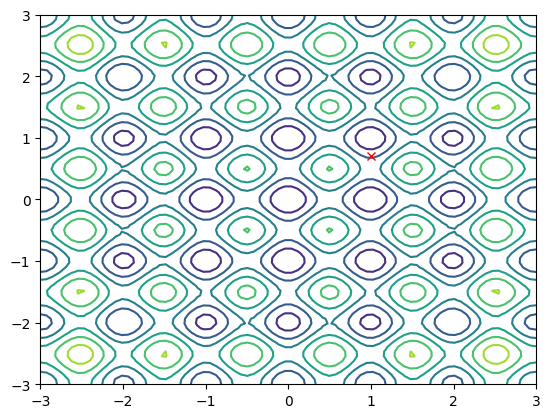

In [27]:
# Plot the function!
plt.close()
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

N = 80
x1 = np.linspace(-3., 3., N)
x2 = np.linspace(-3., 3., N)

X, Y = np.meshgrid(x1, x2)

val = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        xx = np.zeros((2, 1))
        xx[0] = X[i, j]
        xx[1] = Y[i, j]
        val[i, j] = f(xx)

CS = ax.contour(x1.reshape((N,)), x2.reshape((N,)), val)

# Initial point
x0 = np.array([[1., 0.7]]).T
# x0 = np.array([[1., 1.25]]).T # Uncomment and watch it explode!

ax.plot(x0[0, 0], x0[1, 0], 'rx')

print("Initial value:", f(x0))

x = np.copy(x0)

x: [[0.9966487  1.42941263]] -> 22.07124131805434


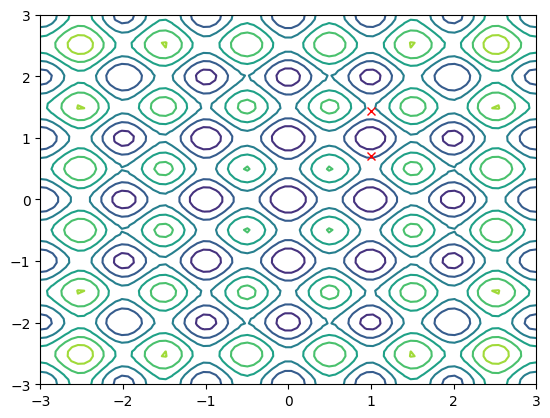

In [28]:
# iterate
x = damped_newton_step(x)

print("x:", x.T, "->", f(x))

ax.plot(x[0, 0], x[1, 0], 'rx')

fig # show figure again with updated point(s)

We are still overshooting and we can explode! We need **line search**! Let's remember the Armijo rule:

$\alpha = 1$

$\text{while } f(\boldsymbol{x}_k + \alpha\Delta\boldsymbol{x}) > f(\boldsymbol{x}_k) + b\alpha\nabla_{\boldsymbol{x}}f(\boldsymbol{x}_k)^T\Delta\boldsymbol{x}:$

$\quad\alpha = c\alpha$

$\boldsymbol{x}_{k+1} = \boldsymbol{x}_k + \alpha\Delta\boldsymbol{x}$

where $0<c<1$ and $b$ is something small.

This procedure helps us to not blow up to infinity and always improve or stay still. The Armijo rule gives us guarantees that we will always reach a local minimum.

Let's create a function that performs a Newton with both regularization and line search:

In [29]:
def armijo_newton_step(x, beta = 1., b = 0.1, c = 0.5):
    ### TO-DO: Implement Damped + Armijo Newton step
    ### Compute Δx (store it in a variabe named `dx`)
    ### BEGIN SOLUTION
    # Write your code here
    ### END SOLUTION
    jacobian = df_dx(x)
    
    gradient = jacobian.T
    hessian = ddf_ddx(x)

    d = hessian.shape[0]
    I = np.eye(d)

    while not is_pos_def(hessian):
        hessian += (beta) * I

    dx = -np.linalg.inv(hessian) @ gradient

    a = 1.0
    fx = f(x)
    gT_dx = (gradient.T @ dx).item()

    while f(x + a * dx) > fx + b * a * gT_dx:
        a = c * a

    return x + a * dx

In [30]:
np.random.seed(10)

x = np.random.randn(2, 1)
xn = armijo_newton_step(x)
assert(np.isclose(xn, np.array([[-1.07868968, 0.72390241]]).T, rtol=1e-3, atol=1e-3).all())

x = np.random.randn(2, 1)
xn = armijo_newton_step(x)
assert(np.isclose(xn, np.array([[-2.89066819, -0.00831666]]).T, rtol=1e-3, atol=1e-3).all())

x = np.random.randn(2, 1)
xn = armijo_newton_step(x)
assert(np.isclose(xn, np.array([[1.95634526, -0.72452386]]).T, rtol=1e-3, atol=1e-3).all())

np.random.seed(None)

Initial value: 14.580169943749475


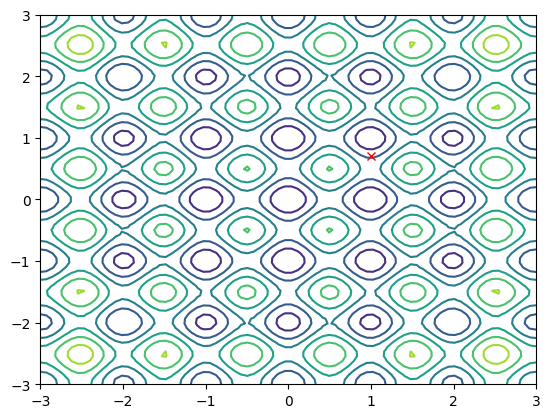

In [39]:
# Let's Optimize!
# Plot the function!
plt.close()
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

N = 80
x1 = np.linspace(-3., 3., N)
x2 = np.linspace(-3., 3., N)

X, Y = np.meshgrid(x1, x2)

val = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        xx = np.zeros((2, 1))
        xx[0] = X[i, j]
        xx[1] = Y[i, j]
        val[i, j] = f(xx)

CS = ax.contour(x1.reshape((N,)), x2.reshape((N,)), val)

# Initial point
x0 = np.array([[1., 0.7]]).T
# x0 = np.array([[1., 1.25]]).T # It was failing with Damped alone! Now it finds the closest local minima!

ax.plot(x0[0, 0], x0[1, 0], 'rx')

print("Initial value:", f(x0))

x = np.copy(x0)

x: [[0.99495864 0.99495864]] -> 1.9899181141865832


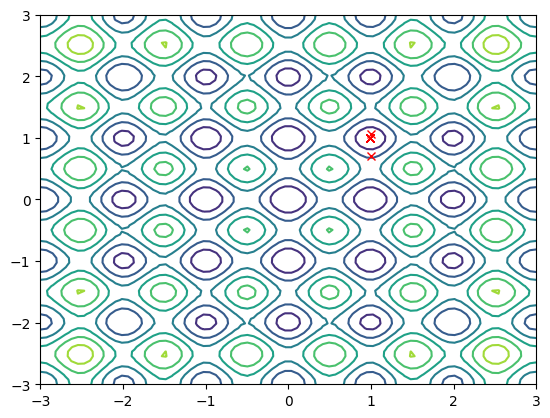

In [52]:
# iterate
x = armijo_newton_step(x)

print("x:", x.T, "->", f(x))

ax.plot(x[0, 0], x[1, 0], 'rx')

fig # show figure again with updated point(s)

### Quadratic Programming

A special case of constrained optimization that is very useful in control and robotics is the **Quadratric Programming** (QP) problem:

$\min_{\boldsymbol{x}}f(\boldsymbol{x}) = \frac{1}{2}\boldsymbol{x}^T\boldsymbol{Q}\boldsymbol{x} + \boldsymbol{q}^T\boldsymbol{x}$

$\quad\quad\text{s.t. }~~\boldsymbol{A}\boldsymbol{x}-\boldsymbol{b} = \boldsymbol{0}$

$\quad\quad\quad\quad\boldsymbol{C}\boldsymbol{x}-\boldsymbol{d}\leq\boldsymbol{0}$

where $\boldsymbol{x},\boldsymbol{q}\in\mathbb{R}^N$, $\boldsymbol{Q}\succ 0\in\mathbb{R}^{N\times N}$.

We can solve this special case algorithm with the generic **Augmented Lagrangian** or **Interior Point Methods**, but there have been developed many specific methods that optimally exploit the specific structure of the problem. There are many libraries available to use. We will use the [ProxSuite](https://github.com/Simple-Robotics/proxsuite) one that uses a state of the art **proximal method** (based on the Augmented Lagrangian) to solve QP problems.

*ProxSuite* solves problems of the form:

$\min_{\boldsymbol{x}}f(\boldsymbol{x}) = \frac{1}{2}\boldsymbol{x}^T\boldsymbol{Q}\boldsymbol{x} + \boldsymbol{q}^T\boldsymbol{x}$

$\quad\quad\text{s.t. }~~\boldsymbol{A}\boldsymbol{x}-\boldsymbol{b} = \boldsymbol{0}$

$\quad\quad\quad\quad\boldsymbol{l}\leq\boldsymbol{C}\boldsymbol{x}\leq\boldsymbol{u}$

So let's define a QP problem and try to solve it with the *ProxSuite* library. First, let's import the library:

In [33]:
import proxsuite

Now let's try to solve a realistic yet simple QP problem. You are managing a simple portfolio with two assets, $x_1$ and $x_2$, representing the proportion of total wealth invested in each. You want to:
1. Minimize the portfolio variance, while
2. Achieving a desired return, and
3. Ensuring full investment (i.e., all wealth is invested).

Let's describe this as a QP problem:

$\min_{\boldsymbol{x} \in \mathbb{R}^2} \quad \frac{1}{2} \boldsymbol{x}^\top \boldsymbol{\Sigma} \boldsymbol{x}$

$\text{s.t.} \quad\quad\quad \boldsymbol{\mu}^\top \boldsymbol{x} \geq r_d$

$ \quad\quad\quad\quad\boldsymbol{1}^\top \boldsymbol{x} = 1$

$ \quad\quad\quad\quad\boldsymbol{x} \geq \boldsymbol{0}$

An example of parameters is:

$\boldsymbol{\Sigma} = \begin{bmatrix} 0.0100 & 0.0018 \\ 0.0018 & 0.0109\end{bmatrix}, \quad \boldsymbol{\mu} = \begin{bmatrix}0.10 \\0.12\end{bmatrix}, \quad r_d = 0.11$

Let's create the problem and solve it using ProxQP.

In [34]:
# Generate a random non-trivial quadratic program.
n = 2 # number of dimensions of the optimization variables (x)
m = 1 # number of inequality constraints
p = 1 # number of equality constraints

# Let's get the cost
Q = np.array([[0.01, 0.0018], [0.0018, 0.0109]])
q = np.zeros((n,))

# Inequality constraints
C = np.array([[0.1, 0.12]])
ubc = None
lbc = np.array([0.11])

# Equality constraints
A = np.ones((p, n))
b = np.ones((p,))

# Bounds
lb = np.zeros((n))
ub = None

In [35]:
# Let's create the solver
qp_dim = Q.shape[0]
qp_dim_eq = A.shape[0]
qp_dim_in = C.shape[0]
qp = proxsuite.proxqp.dense.QP(qp_dim, qp_dim_eq, qp_dim_in, True)

# initialize the model of the problem to solve
qp.init(Q, q, A, b, C, lbc, ubc, lb, ub)
qp.solve()

# Get the result
print("optimal x: {}".format(qp.results.x))
print("Objective value: {}".format(qp.results.info.objValue))

optimal x: [0.50009215 0.49990798]
Objective value: 0.0030624594784276135


So now we can easily define QP problems, give them to *ProxSuite* and get back the results! Easy!

### General Non-Linear Programming (NLP)

What if we have a general non linear problem with constraints that we want to minimize/optimize? We can implement the **Augmented Lagrangian Method** but in practice many small tricks are needed to have a robust solver. So what should we do? Luckily, there are quite a few good libraries out there for solving generic NLP problems. In this course, we will use [Ipopt](https://github.com/coin-or/Ipopt).

Ipopt solves generic NLP problems with any type of objective functions and constraints. We need to provide to Ipopt:

1) The objective function and its gradient
2) The constraints and their Jacobians
3) Bounds to the variables

Then Ipopt does all the job and we get back a nice result (most of the times!). In the backed, Ipopt uses a **Primal-Dual Interior Point Method**.

So let's see it in action! First we import the Python bindings of the library.

In [36]:
import cyipopt

Let's optimize the following function:

$f(\boldsymbol{x}) = (x_1-2)^2 + (x_2-1)^2$

with the following constraints:

$h(\boldsymbol{x}) = x_1-2\,x_2+1=0$

$g(\boldsymbol{x}) = 0.25\,{x_1^2}+x_2^2-1\leqslant 0$

The best known optimal feasible solution is $f(\boldsymbol{x^*}) = 1.3934651$.

In [37]:
# So here's how to write this for cyipopt
class IpoptOptimization:
    def __init__(self):
        pass

    def objective(self, x):
        return (x[0] - 2.)**2 + (x[1]-1.)**2

    def gradient(self, x):
        return np.asarray([2. * (x[0] - 2.), 2. * (x[1] - 1.)])

    def constraints(self, x):
        c = np.zeros((2,))

        # Equality
        c[0] = x[0] - 2. * x[1] + 1.
        # Inequality
        c[1] = 0.25 * x[0] * x[0] + x[1] * x[1] - 1.

        return c

    def jacobian(self, x):
        J = np.zeros((2, 2))
        # Gradient of 1st constraint wrt to x1
        J[0, 0] = 1.
        # Gradient of 1st constraint wrt to x2
        J[0, 1] = -2.

        # Gradient of 2nd constraint wrt to x1
        J[1, 0] = 0.5 * x[0]
        # Gradient of 2nd constraint wrt to x2
        J[1, 1] = 2. * x[1]
        
        return J

# Let's give a zero initial guess
x0 = np.zeros((2,))

# Bounds for constraints
cl = np.zeros((2,))
cl[1] = -np.inf # Inequality has no lower bound

cu = np.zeros((2,))

# Let's solve the problem
nlp = cyipopt.Problem(n=2, m=2, problem_obj=IpoptOptimization(), lb=[None]*2, ub=[None]*2, cl=cl, cu=cu)

nlp.add_option("jacobian_approximation", "exact") # "finite-difference-values")
nlp.add_option("print_level", 3)
nlp.add_option("nlp_scaling_method", "none")


# Solve the problem
x, info = nlp.solve(x0)

# Optimal
print("x:", x)
print("obj:", info['obj_val'])

x:
******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt
******************************************************************************

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1


Number of Iterations....: 6

   